# Customer Churn Prediction — Data Understanding

## Objective

The objective of this project is to understand customer data and identify
patterns that may be associated with customer churn.

Before performing data cleaning, exploratory data analysis, and machine
learning, we first need to understand the structure, quality, and distribution
of the dataset.

In [6]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('\n Libraries imported sucessfully ')


 Libraries imported sucessfully 


In [7]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("\n Data set imported syccessfully ")


 Data set imported syccessfully 


In [8]:
# create a copy of df as data
data = df.copy()

## 1. Initial Data Inspection

We begin by examining the first and last few records to understand the
structure and type of information contained in the dataset.

In [9]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### Dataset Shape

The shape of the dataset tells us how many observations and features are
available.

In [12]:
data.shape

(7043, 21)

In [14]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Data Types

Understanding data types is important because different types of variables
require different preprocessing techniques.

For example:
- Numerical variables can be used for mathematical calculations.
- Categorical variables need to be encoded before being used by most ML models.

In [15]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Numerical Feature Summary

We examine descriptive statistics for numerical variables to understand
their central tendency, spread, and range.

In [17]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
data.describe(include= "str") 

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 2. Missing Value Investigation

Missing values can affect analysis and machine learning models.
We first check for standard missing values represented as NaN.

In [20]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
data.isnull().sum().sum()

np.int64(0)

In [22]:
missing_percentage = (
    data.isnull().sum() / len(data) * 100
).sort_values(ascending=False)

missing_percentage

customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0.0
MultipleLines       0.0
PhoneService        0.0
tenure              0.0
Dependents          0.0
Partner             0.0
SeniorCitizen       0.0
Churn               0.0
dtype: float64

## 3. Duplicate Investigation

Duplicate records can cause certain customers to be counted multiple times
and may affect analysis and model training.

In [23]:
data.duplicated().sum()

np.int64(0)

In [24]:
data["customerID"].duplicated().sum()

np.int64(0)

In [26]:
for column in data.select_dtypes(include="str").columns:
    print(f"\n {column} ")
    print(f"\n {data[column].unique()}")


 customerID 

 <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

 gender 

 <StringArray>
['Female', 'Male']
Length: 2, dtype: str

 Partner 

 <StringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents 

 <StringArray>
['No', 'Yes']
Length: 2, dtype: str

 PhoneService 

 <StringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines 

 <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService 

 <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 OnlineSecurity 

 <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 OnlineBackup 

 <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

 DeviceProtection 

 <StringArra

In [27]:
data.nunique().sort_values()

Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

## 4. Investigating TotalCharges

`TotalCharges` represents the total amount charged to a customer, so it should
be a numerical feature.

However, the dataset stores this column as an object.

We need to investigate why before converting it to a numerical data type.

In [28]:
data["TotalCharges"].value_counts().tail(20)

TotalCharges
6479.4     1
3626.35    1
1679.4     1
403.35     1
931.55     1
4326.25    1
263.05     1
39.25      1
3316.1     1
75.75      1
2625.25    1
6886.25    1
1495.1     1
743.3      1
1419.4     1
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, dtype: int64

In [29]:
data["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [30]:
data["TotalCharges"].str.contains(r"[^\d.]").sum()

np.int64(11)

In [31]:
invalid_total_charges = data[
    data["TotalCharges"].str.strip() == ""
]

invalid_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 5. Target Variable — Churn

The target variable is `Churn`.

It indicates whether a customer has left the company:

- Yes → Customer churned
- No → Customer stayed

In [32]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
data["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [34]:
data["Churn"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [37]:
numeric_column = data.select_dtypes(include= np.number).columns
numeric_column

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [39]:
data[numeric_column].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [40]:
categorical_column = data.select_dtypes(include= "str").columns
categorical_column

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

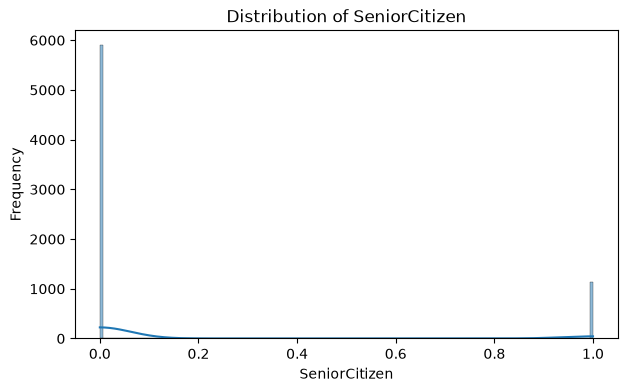

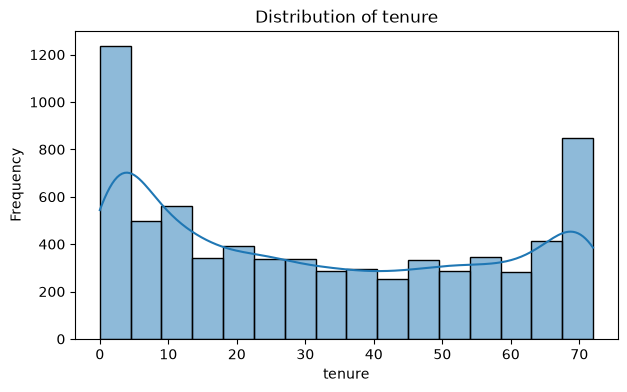

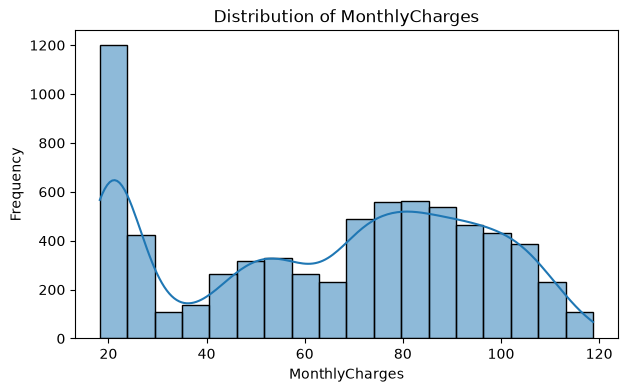

In [41]:
for column in numeric_column:
    plt.figure(figsize=(7, 4))
    sns.histplot(data[column], kde= True)  # type: ignore
    plt.title(f" Distribution of {column} ")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

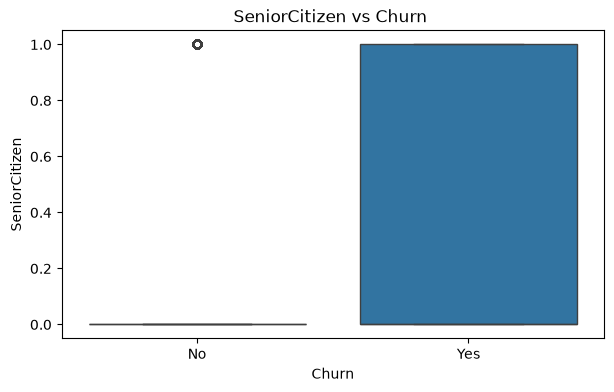

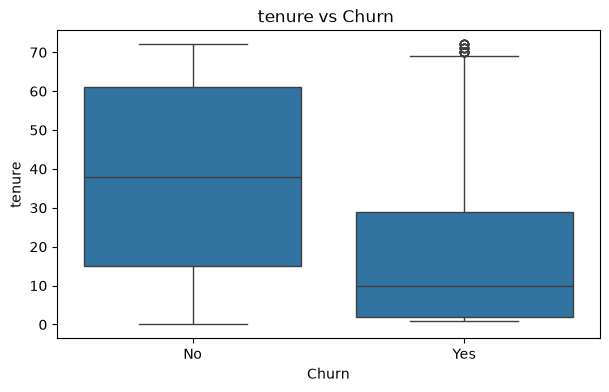

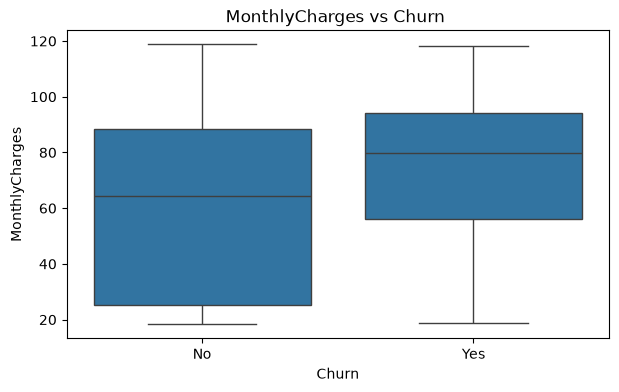

In [42]:
for column in numeric_column:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x= "Churn", y= column, data= data)
    plt.title(f"{column} vs Churn ")
    plt.show()

## Data Understanding — Initial Findings

The dataset contains 7,043 customer records and 21 features.

Key observations:

1. The target variable is `Churn`, making this a binary classification problem.

2. The dataset contains both numerical and categorical variables.

3. `TotalCharges` is stored as an object even though it represents a numerical
   quantity. Further investigation revealed whitespace values that need to be
   handled during data cleaning.

4. The dataset contains approximately 26.5% churned customers and 73.5%
   non-churned customers, indicating moderate class imbalance.

5. `customerID` is an identifier and should not be used as a predictive feature.

6. Further analysis is required to investigate missing values, categorical
   distributions, numerical distributions, outliers, and relationships between
   customer characteristics and churn.